1. Import und Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

2. Daten einlesen

In [3]:
file_path = "../data/cleaned_wlags_Number_of_fires_by_month.csv"
# CSV mit Semikolon-Trenner einlesen
df_fires = pd.read_csv(file_path, sep=",", header=0, encoding="ISO-8859-1")
print(df_fires.columns)


Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')


In [4]:
file_path = "../data/cleaned_British_Columbia_monthly_mean.csv"
# CSV mit Semikolon-Trenner einlesen
df_weather = pd.read_csv(file_path, sep=",", header=0, encoding="ISO-8859-1")
print(df_fires.columns)

Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')





3. Datenbereinigung

In [5]:
# Monat numerisch machen
df_fires["Month"] = pd.to_datetime(df_fires["Month"], format="%B").dt.month

# sicherstellen, dass 'time' ein Datetime ist
df_weather["time"] = pd.to_datetime(df_weather["time"])

# Jahr und Monat extrahieren
df_weather["Year"] = df_weather["time"].dt.year
df_weather["Month"] = df_weather["time"].dt.month
df_weather = df_weather.drop(columns=["time"])

#filter british columbia
df_fires_bc = df_fires[df_fires["Jurisdiction"] == "British Columbia"].copy()
df_fires_bc["Jurisdiction"].unique()

array(['British Columbia'], dtype=object)

4. Merge data

In [6]:
print(df_fires_bc.columns)
print(df_weather.columns)


Index(['Jurisdiction', 'Month', 'Year', 'Number_fires'], dtype='object')
Index(['temperature_2m_mean (Â°C)', 'temperature_2m_max (Â°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (Â°)', 'et0_fao_evapotranspiration (mm)',
       'Year', 'Month'],
      dtype='object')


In [7]:
df_merged = pd.merge(
    df_fires_bc,
    df_weather,
    on=["Year", "Month"],
    how="inner"
)

In [8]:
print(df_merged.columns)
print(df_merged.dtypes)
df_merged.head(10)
print(df_merged.shape)
duplicates = df_merged.duplicated(subset=["Jurisdiction", "Year", "Month"]).sum()
print("Doppelte Schlüssel:", duplicates)
df_merged.isna().sum()

Index(['Jurisdiction', 'Month', 'Year', 'Number_fires',
       'temperature_2m_mean (Â°C)', 'temperature_2m_max (Â°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (Â°)', 'et0_fao_evapotranspiration (mm)'],
      dtype='object')
Jurisdiction                         object
Month                                 int32
Year                                  int64
Number_fires                        float64
temperature_2m_mean (Â°C)           float64
temperature_2m_max (Â°C)            float64
relative_humidity_2m_mean (%)       float64
relative_humidity_2m_min (%)        float64
precipitation_sum (mm)              float64
precipitation_hours (h)             float64
wind_speed_10m_mean (km/h)          float64
wind_speed_10m_max (km/h)           float64
wind_direction_10m_dominant (Â°)    float64
et0_fao_e

Jurisdiction                         0
Month                                0
Year                                 0
Number_fires                        29
temperature_2m_mean (Â°C)            0
temperature_2m_max (Â°C)             0
relative_humidity_2m_mean (%)        0
relative_humidity_2m_min (%)         0
precipitation_sum (mm)               0
precipitation_hours (h)              0
wind_speed_10m_mean (km/h)           0
wind_speed_10m_max (km/h)            0
wind_direction_10m_dominant (Â°)     0
et0_fao_evapotranspiration (mm)      0
dtype: int64

5. Korrelationsanalyse

In [9]:
corr_cols = [
    "Number_fires",
    "temperature_2m_mean (Â°C)",
    "relative_humidity_2m_mean (%)",
    "precipitation_sum (mm)",
    "wind_speed_10m_mean (km/h)",
    "et0_fao_evapotranspiration (mm)"
]

df_corr = df_merged[corr_cols].dropna()


In [10]:
pearson_corr = df_corr.corr(method="pearson")
print(pearson_corr)


                                 Number_fires  temperature_2m_mean (Â°C)  \
Number_fires                         1.000000                   0.641698   
temperature_2m_mean (Â°C)            0.641698                   1.000000   
relative_humidity_2m_mean (%)       -0.601578                  -0.778067   
precipitation_sum (mm)              -0.147455                   0.080547   
wind_speed_10m_mean (km/h)          -0.400625                  -0.403046   
et0_fao_evapotranspiration (mm)      0.649688                   0.923596   

                                 relative_humidity_2m_mean (%)  \
Number_fires                                         -0.601578   
temperature_2m_mean (Â°C)                            -0.778067   
relative_humidity_2m_mean (%)                         1.000000   
precipitation_sum (mm)                                0.269074   
wind_speed_10m_mean (km/h)                            0.289910   
et0_fao_evapotranspiration (mm)                      -0.894838   

    

In [11]:
spearman_corr = df_corr.corr(method="spearman")
print(spearman_corr)


                                 Number_fires  temperature_2m_mean (Â°C)  \
Number_fires                         1.000000                   0.917959   
temperature_2m_mean (Â°C)            0.917959                   1.000000   
relative_humidity_2m_mean (%)       -0.865109                  -0.784080   
precipitation_sum (mm)              -0.104771                   0.044543   
wind_speed_10m_mean (km/h)          -0.422116                  -0.425969   
et0_fao_evapotranspiration (mm)      0.916007                   0.929873   

                                 relative_humidity_2m_mean (%)  \
Number_fires                                         -0.865109   
temperature_2m_mean (Â°C)                            -0.784080   
relative_humidity_2m_mean (%)                         1.000000   
precipitation_sum (mm)                                0.275942   
wind_speed_10m_mean (km/h)                            0.298242   
et0_fao_evapotranspiration (mm)                      -0.904643   

    

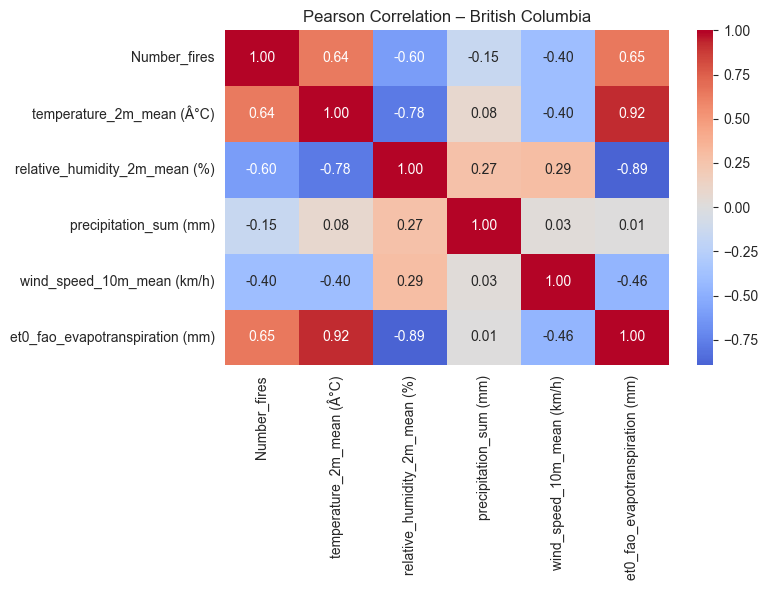

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation – British Columbia")
plt.tight_layout()
plt.show()


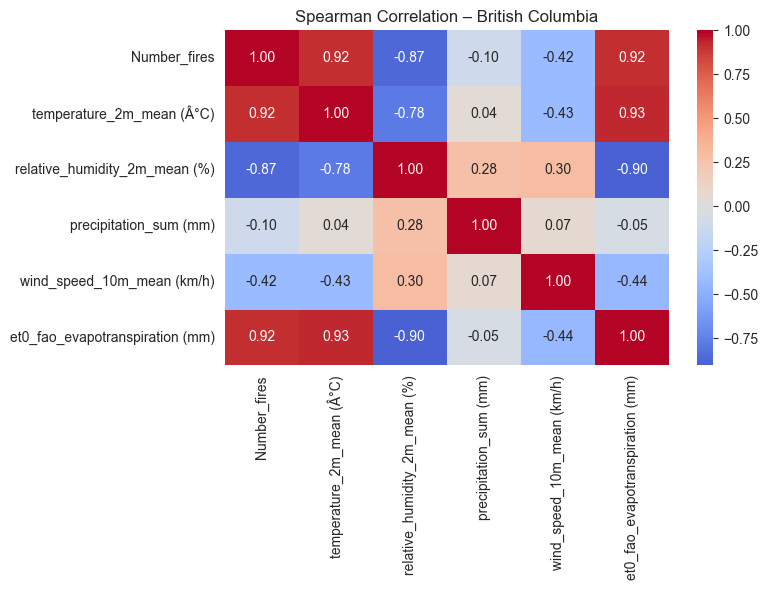

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation – British Columbia")
plt.tight_layout()
plt.show()

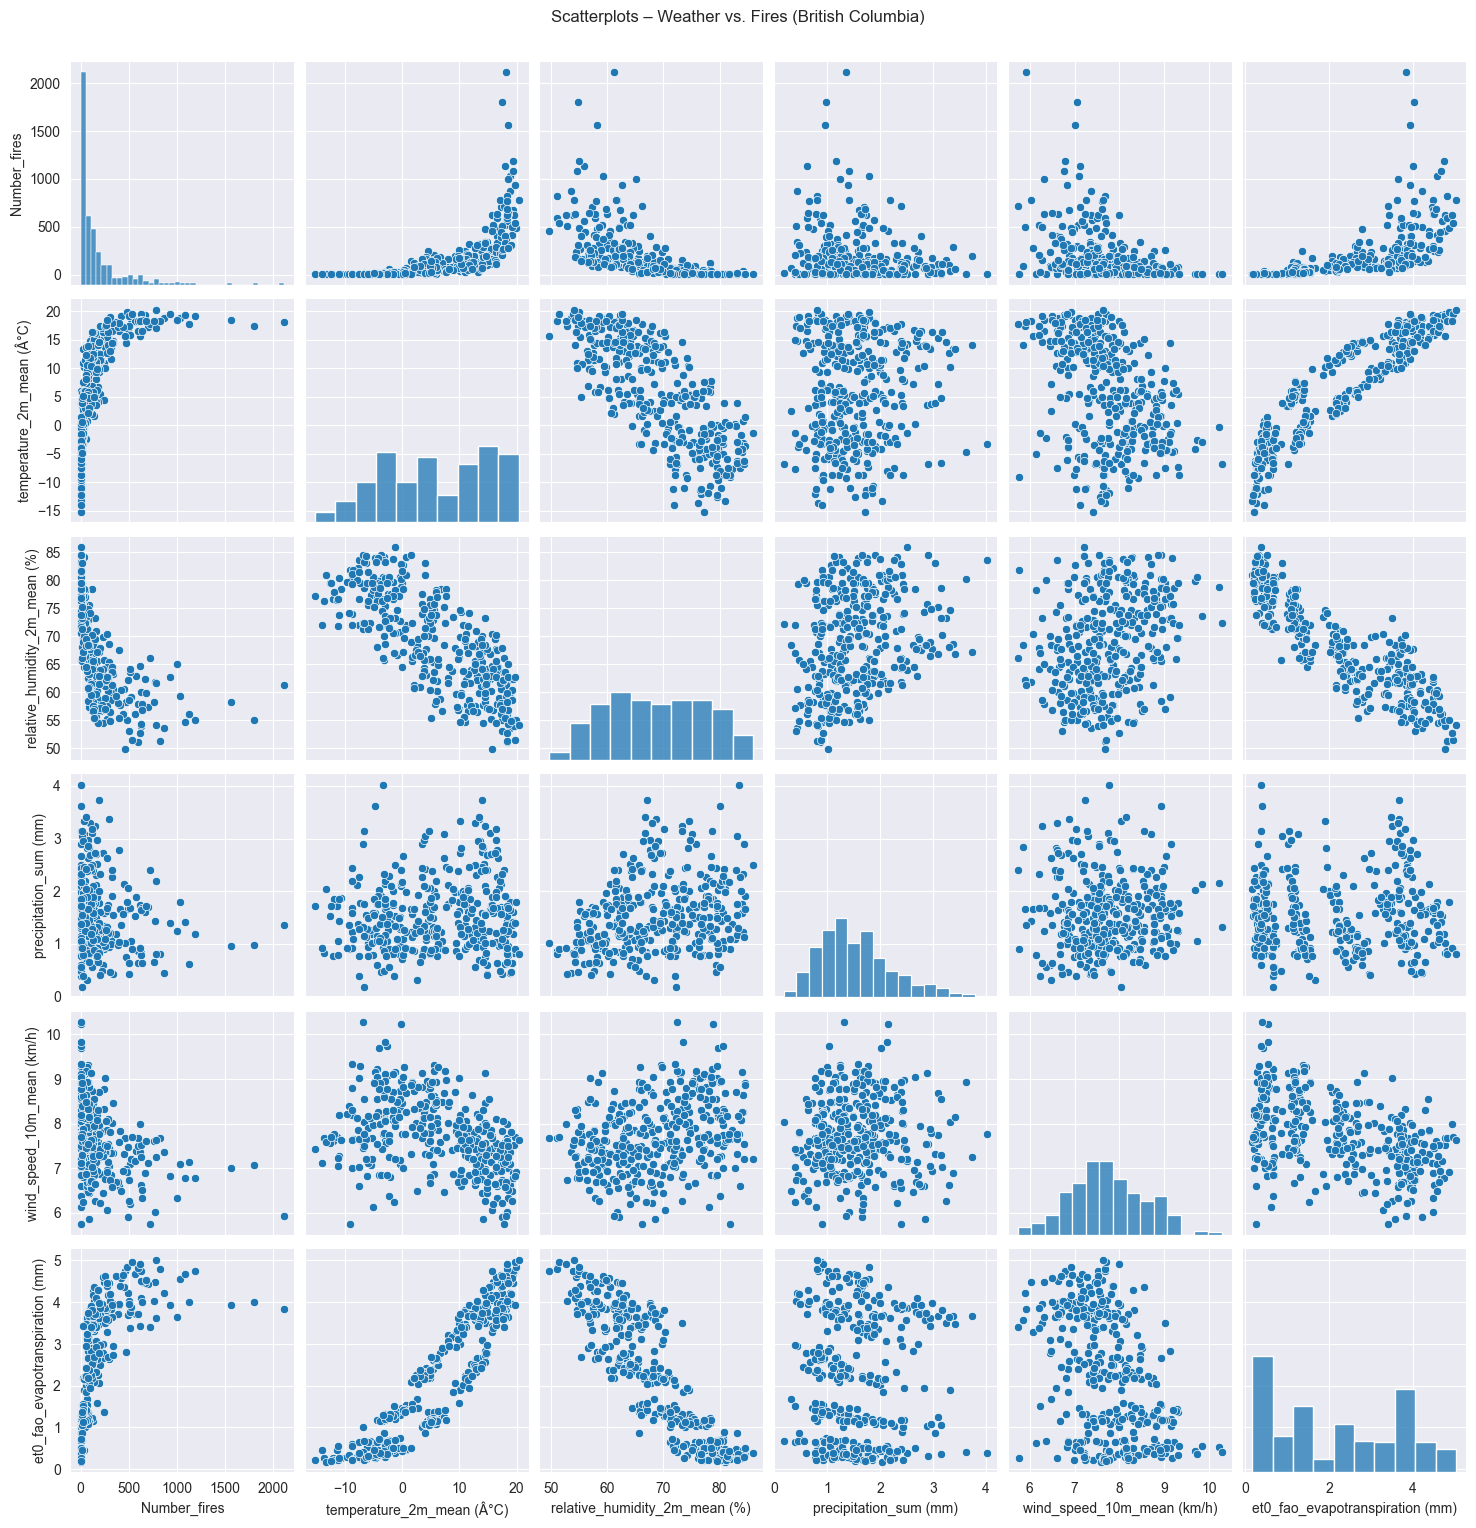

In [14]:
sns.pairplot(
    df_corr,
    kind="scatter",
    diag_kind="hist"
)
plt.suptitle("Scatterplots – Weather vs. Fires (British Columbia)", y=1.02)
plt.show()
